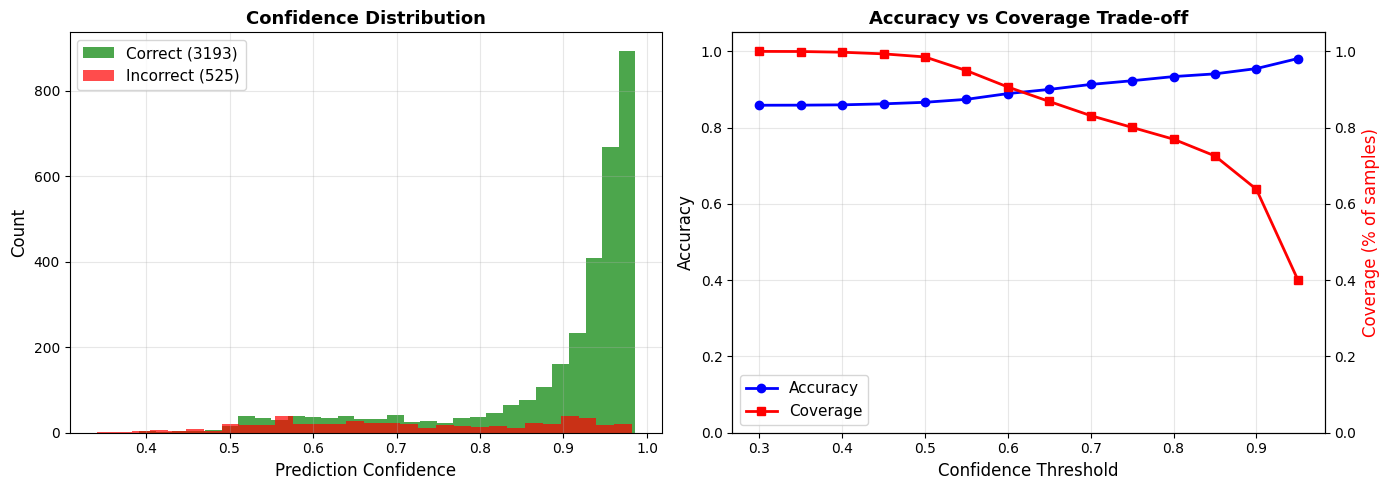

In [21]:
pred_confidence = np.max(all_probs, axis=1)
correct_mask = all_preds == all_labels

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confidence distribution for correct vs incorrect
axes[0].hist(pred_confidence[correct_mask], bins=30, alpha=0.7,
             label=f'Correct ({correct_mask.sum()})', color='green')
axes[0].hist(pred_confidence[~correct_mask], bins=30, alpha=0.7,
             label=f'Incorrect ({(~correct_mask).sum()})', color='red')
axes[0].set_xlabel('Prediction Confidence', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Confidence Distribution', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Accuracy vs Coverage at different thresholds
thresholds = np.arange(0.3, 1.0, 0.05)
accs_at_thresh = []
coverage_at_thresh = []

for thresh in thresholds:
    mask = pred_confidence >= thresh
    if mask.sum() > 0:
        accs_at_thresh.append(accuracy_score(all_labels[mask], all_preds[mask]))
        coverage_at_thresh.append(mask.sum() / len(mask))
    else:
        accs_at_thresh.append(np.nan)
        coverage_at_thresh.append(0)

ax1 = axes[1]
ax2 = ax1.twinx()

ax1.plot(thresholds, accs_at_thresh, 'b-o', label='Accuracy', linewidth=2)
ax2.plot(thresholds, coverage_at_thresh, 'r-s', label='Coverage', linewidth=2)

ax1.set_xlabel('Confidence Threshold', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12, color='black')
ax2.set_ylabel('Coverage (% of samples)', fontsize=12, color='red')
ax1.set_title('Accuracy vs Coverage Trade-off', fontsize=13, fontweight='bold')
ax1.set_ylim(0, 1.05)
ax2.set_ylim(0, 1.05)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=11, loc='lower left')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

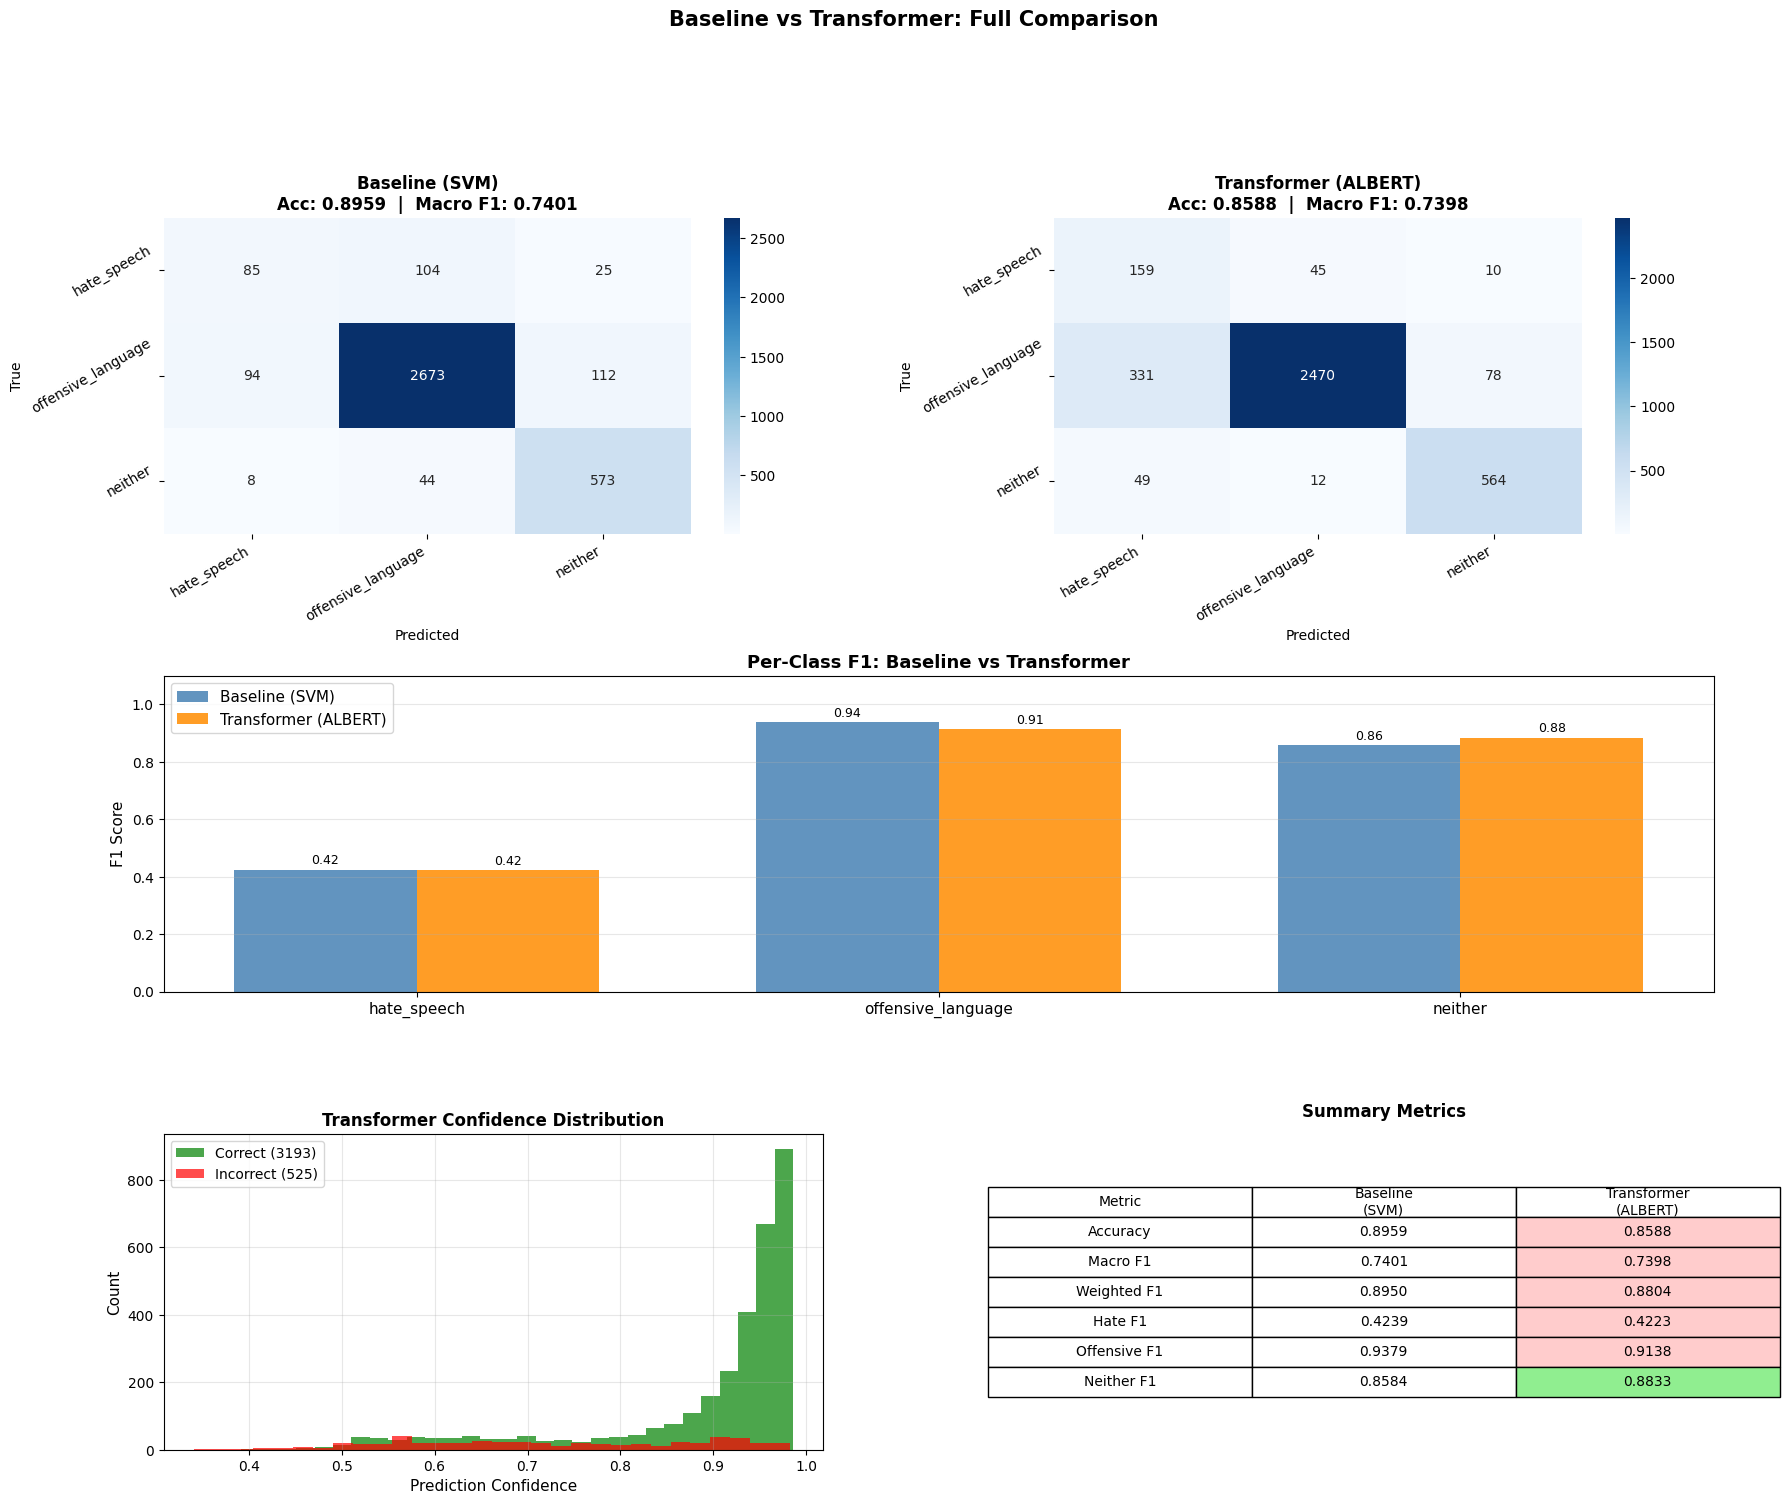

In [22]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
import matplotlib.gridspec as gridspec

best_results = baseline_predictions[best_model_name]
baseline_preds = np.array(best_results["y_pred"])
baseline_labels = np.array(best_results[y_test.name])

# ---- Confusion matrices ----
cm_baseline   = confusion_matrix(baseline_labels, baseline_preds)
cm_transformer = confusion_matrix(all_labels, all_preds)

fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# --- Row 1: Confusion matrices ---
for col, (cm, title, preds, labels) in enumerate([
    (cm_baseline,    f"Baseline ({best_model_name})", baseline_preds, baseline_labels),
    (cm_transformer, "Transformer (ALBERT)",          all_preds,      all_labels),
]):
    ax = fig.add_subplot(gs[0, col])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names, ax=ax
    )
    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, average="macro")
    ax.set_title(f"{title}\nAcc: {acc:.4f}  |  Macro F1: {f1:.4f}",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("True", fontsize=10)
    ax.set_xticklabels(class_names, rotation=30, ha="right")
    ax.set_yticklabels(class_names, rotation=30)

# --- Row 2: Per-class F1 bar chart ---
report_baseline     = classification_report(baseline_labels, baseline_preds,
                                            target_names=class_names, output_dict=True)
report_transformer  = classification_report(all_labels, all_preds,
                                            target_names=class_names, output_dict=True)

per_class_f1_baseline    = [report_baseline[c]["f1-score"]    for c in class_names]
per_class_f1_transformer = [report_transformer[c]["f1-score"] for c in class_names]

x = np.arange(len(class_names))
width = 0.35

ax = fig.add_subplot(gs[1, :])  # span full width
bars1 = ax.bar(x - width/2, per_class_f1_baseline,    width, label=f"Baseline ({best_model_name})", color="steelblue",  alpha=0.85)
bars2 = ax.bar(x + width/2, per_class_f1_transformer, width, label="Transformer (ALBERT)",          color="darkorange", alpha=0.85)

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(class_names, fontsize=11)
ax.set_ylabel("F1 Score", fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title("Per-Class F1: Baseline vs Transformer", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis="y")

# --- Row 3: Confidence distribution (transformer only) + summary table ---
pred_confidence = np.max(all_probs, axis=1)
correct_mask    = all_preds == all_labels

ax_conf = fig.add_subplot(gs[2, 0])
ax_conf.hist(pred_confidence[correct_mask],  bins=30, alpha=0.7,
             label=f"Correct ({correct_mask.sum()})",   color="green")
ax_conf.hist(pred_confidence[~correct_mask], bins=30, alpha=0.7,
             label=f"Incorrect ({(~correct_mask).sum()})", color="red")
ax_conf.set_xlabel("Prediction Confidence", fontsize=11)
ax_conf.set_ylabel("Count", fontsize=11)
ax_conf.set_title("Transformer Confidence Distribution", fontsize=12, fontweight="bold")
ax_conf.legend(fontsize=10)
ax_conf.grid(True, alpha=0.3)

# --- Row 3: Summary metrics table ---
ax_tbl = fig.add_subplot(gs[2, 1])
ax_tbl.axis("off")

metrics = ["Accuracy", "Macro F1", "Weighted F1",
           "Hate F1", "Offensive F1", "Neither F1"]
baseline_vals = [
    f"{accuracy_score(baseline_labels, baseline_preds):.4f}",
    f"{f1_score(baseline_labels, baseline_preds, average='macro'):.4f}",
    f"{f1_score(baseline_labels, baseline_preds, average='weighted'):.4f}",
    f"{report_baseline['hate_speech']['f1-score']:.4f}",
    f"{report_baseline['offensive_language']['f1-score']:.4f}",
    f"{report_baseline['neither']['f1-score']:.4f}",
]
transformer_vals = [
    f"{accuracy_score(all_labels, all_preds):.4f}",
    f"{f1_score(all_labels, all_preds, average='macro'):.4f}",
    f"{f1_score(all_labels, all_preds, average='weighted'):.4f}",
    f"{report_transformer['hate_speech']['f1-score']:.4f}",
    f"{report_transformer['offensive_language']['f1-score']:.4f}",
    f"{report_transformer['neither']['f1-score']:.4f}",
]

table = ax_tbl.table(
    cellText=[[m, b, t] for m, b, t in zip(metrics, baseline_vals, transformer_vals)],
    colLabels=["Metric", f"Baseline\n({best_model_name})", "Transformer\n(ALBERT)"],
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

# Highlight transformer wins in green, losses in red
for row_idx, (bv, tv) in enumerate(zip(baseline_vals, transformer_vals), start=1):
    color = "lightgreen" if float(tv) >= float(bv) else "#ffcccc"
    table[row_idx, 2].set_facecolor(color)

ax_tbl.set_title("Summary Metrics", fontsize=12, fontweight="bold", pad=12)

plt.suptitle("Baseline vs Transformer: Full Comparison", fontsize=15, fontweight="bold", y=1.01)
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()